In [1]:
import os
from pathlib import Path
import sys

In [2]:
import numpy as np
import pandas as pd

In [3]:
from scipy.stats import gaussian_kde

In [4]:
%matplotlib inline

In [5]:
import matplotlib.pyplot as plt

## 1. Load the Data

In [6]:
data_path = Path(os.getcwd()).parent / "data" / "eurpln_2001-2025.csv"
data = pd.read_csv(data_path, sep=",", decimal=".")
data.columns = [c.lower() for c in data.columns]
data = data.set_index("date")

In [7]:
data.head()

,open,high,low,close
date,,,,
2001-01-02,3.8640,3.8763,3.8431,3.8533
2001-01-03,3.8720,3.9077,3.8600,3.8987
2001-01-04,3.9003,3.9123,3.8600,3.8992
2001-01-05,3.8991,3.9259,3.8690,3.9095
2001-01-08,3.9031,3.9135,3.8774,3.8890


Text(0.5, 1.0, 'EURPLN rate daily close prices 2001-2025')

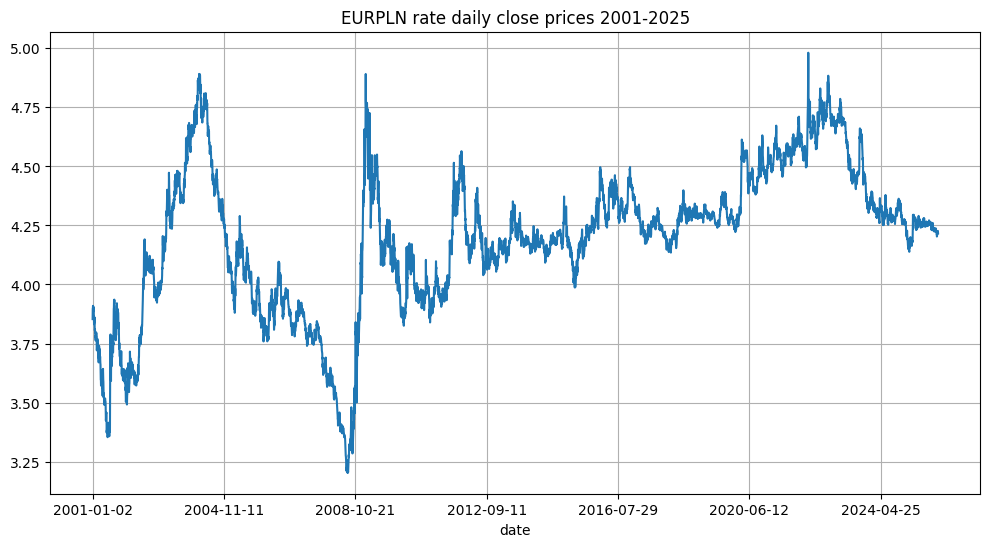

In [8]:
data.head()
#%%
fig_full_hist = plt.figure(figsize=(12, 6))
ax_full_hist = fig_full_hist.add_subplot(111)
data["close"].plot(ax=ax_full_hist)
ax_full_hist.grid(True)
ax_full_hist.set_title("EURPLN rate daily close prices 2001-2025")

## 2. Log-Returns - Histogram, KDE

In [9]:
data = data[["close"]]

In [10]:
data["lr_close"] = np.log(data["close"]).diff()

Text(0.5, 1.0, 'Log-returns of EURPLN rate')

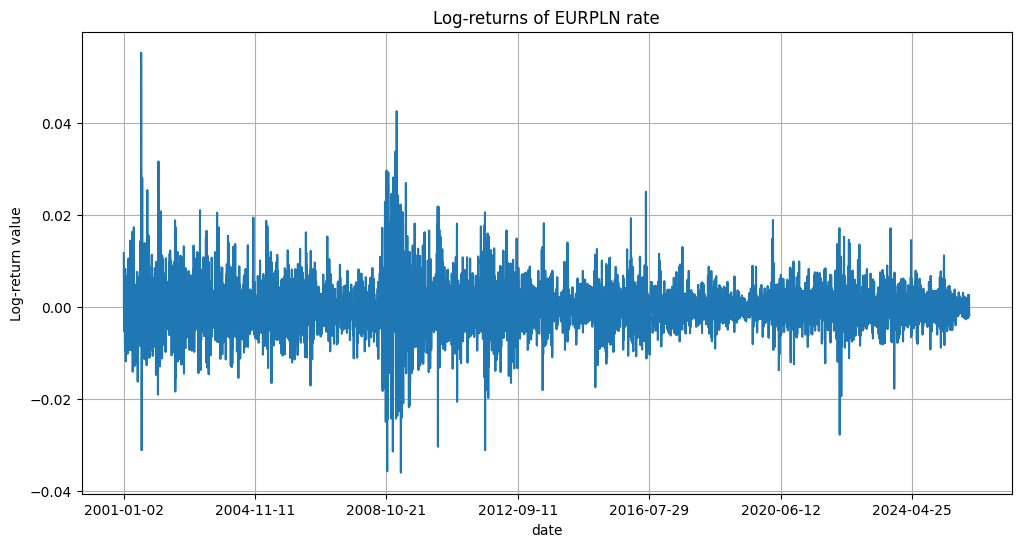

In [11]:
fig_lr = plt.figure(figsize=(12, 6))
ax_lr = fig_lr.add_subplot(111)
data["lr_close"].plot(ax=ax_lr)
ax_lr.grid(True)
ax_lr.set_ylabel("Log-return value")
ax_lr.set_title("Log-returns of EURPLN rate")

In [12]:
data["lr_close_lag1"] = data["lr_close"].shift(1)
data.head()

,close,lr_close,lr_close_lag1
date,,,
2001-01-02,3.8533,NaN,NaN
2001-01-03,3.8987,0.011713,NaN
2001-01-04,3.8992,0.000128,0.011713
2001-01-05,3.9095,0.002638,0.000128
2001-01-08,3.8890,-0.005257,0.002638


In [13]:
data = data.loc[data.isna().sum(axis=1) == 0, :]

In [14]:
data.head()

,close,lr_close,lr_close_lag1
date,,,
2001-01-04,3.8992,0.000128,0.011713
2001-01-05,3.9095,0.002638,0.000128
2001-01-08,3.8890,-0.005257,0.002638
2001-01-09,3.9034,0.003696,-0.005257
2001-01-10,3.8860,-0.004468,0.003696


Text(0, 0.5, 'log-return at t')

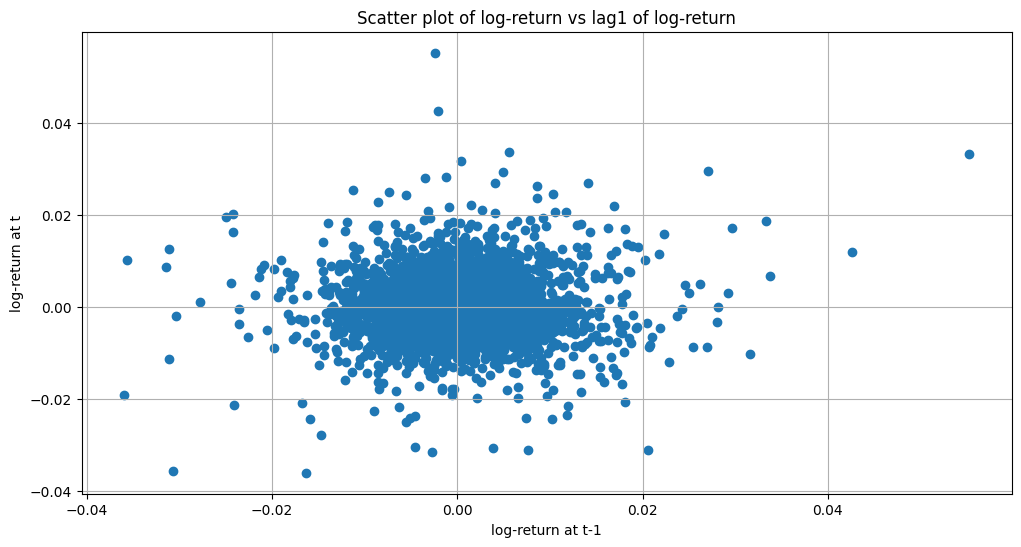

In [15]:
fig_lr_scatter = plt.figure(figsize=(12, 6))
ax_lr_scatter = fig_lr_scatter.add_subplot(111)
ax_lr_scatter.scatter(data["lr_close_lag1"], data["lr_close"])
ax_lr_scatter.grid(True)
ax_lr_scatter.set_title("Scatter plot of log-return vs lag1 of log-return")
ax_lr_scatter.set_xlabel("log-return at t-1")
ax_lr_scatter.set_ylabel("log-return at t")

In [16]:
kde = gaussian_kde(data["lr_close"])

In [17]:
x_kde = np.linspace(data["lr_close"].min(), data["lr_close"].max(), 200)

Text(0.5, 1.0, 'Histogram & KDE of log-returns of EURPLN')

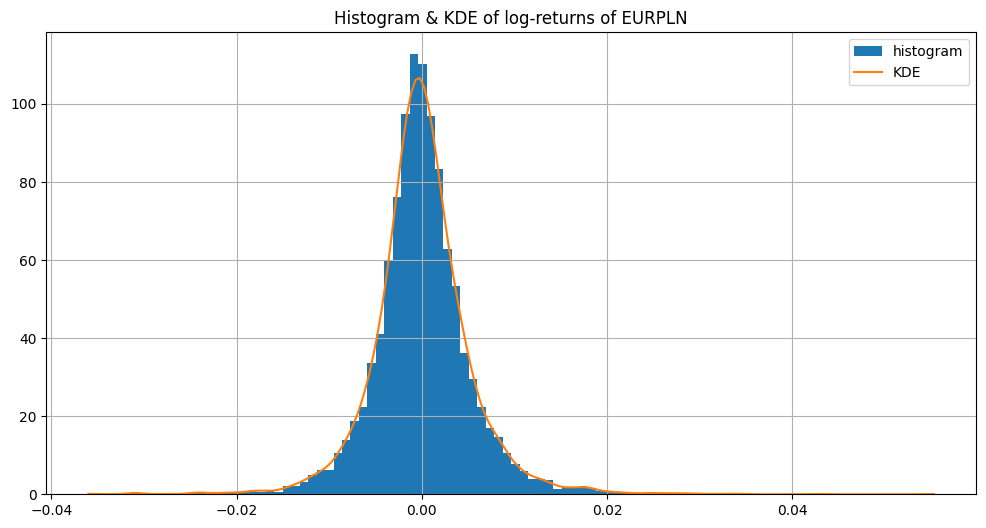

In [18]:
fig_hist = plt.figure(figsize=(12, 6))
ax_hist = fig_hist.add_subplot(111)
_ = ax_hist.hist(data["lr_close"], bins=100, density=True, label="histogram")
ax_hist.plot(x_kde, kde(x_kde), label="KDE")
ax_hist.grid(True)
ax_hist.legend()
ax_hist.set_title("Histogram & KDE of log-returns of EURPLN")

## 3. Log-Returns' Descriptive Statistics

In [19]:
data.head()

,close,lr_close,lr_close_lag1
date,,,
2001-01-04,3.8992,0.000128,0.011713
2001-01-05,3.9095,0.002638,0.000128
2001-01-08,3.8890,-0.005257,0.002638
2001-01-09,3.9034,0.003696,-0.005257
2001-01-10,3.8860,-0.004468,0.003696


In [20]:
data["lr_close"].describe()

count    6435.000000
mean        0.000012
std         0.005341
min        -0.035996
25%        -0.002614
50%        -0.000148
75%         0.002504
max         0.055271
Name: lr_close, dtype: float64

In [22]:
data["lr_close"].quantile(0.99)

np.float64(0.016159110492383916)

In [23]:
data["lr_close"].quantile(0.01)

np.float64(-0.013703040290678929)